## **Importacion de datos**

In [1387]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample


In [1388]:
df_prueba = pd.read_csv('data/Datos Lab 1.csv')
df_completos = pd.read_csv('data/Datos Lab 1.csv')
df_diccionario = pd.read_excel('data/Diccionario de datos.xlsx')

## **Limpieza y tratamiento de datos**

*Copia de datos*

In [1389]:
dfc_completos = df_completos.copy()
dfc_prueba = df_prueba.copy()
dfc_diccionario = df_diccionario.copy()

*Revision del estado de la dataset*

In [1390]:
((dfc_completos.isnull().sum()/dfc_completos.shape[0])).sort_values(ascending=False) 


temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

En este caso todos tienen valores nulos, entonces realizaremos algunos ajustes para poder llenar los datos faltantes

In [1391]:
# Filtrar filas con Calificación nula
nulos = dfc_completos[dfc_completos['temp_max_manana'].isna()].copy()

# Contar cuántas son
print(f"Filas con temp_max_manana nula: {nulos.shape[0]}")

# Guardar los índices
indices = dfc_completos.index[dfc_completos['temp_max_manana'].isna()]

# Mostrar tabla
nulos

Filas con temp_max_manana nula: 95


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
5,2009-01-06,997.0530,NaN,998.49,1.2689,83.774700,67.310000,89.3,4.8864,1.22680,...,0.6808,-0.0178,358.5028,144.0,2009.0,6.0,invierno,January,N,NaN
15,2009-01-16,997.5481,995.15,999.29,1.1148,92.759700,102.543211,81.5,5.2127,1.59950,...,-1.4937,-0.3001,191.3615,144.0,2009.0,16.0,invierno,JUNE,S,NaN
24,2009-01-25,974.0507,971.14,975.36,1.0433,83.009000,59.270000,95.5,10.9192,0.92620,...,-0.7753,0.0561,175.8584,144.0,2009.0,25.0,invierno,January,NaN,NaN
30,2009-01-31,994.3756,989.95,997.42,2.0522,0.884403,73.300000,94.4,5.4441,2.58660,...,1.9530,1.6026,39.3705,144.0,NaN,31.0,Inverano,april,NE,NaN
32,2009-02-02,979.9558,976.36,982.79,2.2236,80.692600,67.710000,91.4,6.7588,1.48330,...,0.5206,0.7330,54.6159,NaN,2009.0,33.0,invierno,February,Noreste,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379,2015-07-08,983.2930,980.57,986.52,1.6125,61.704600,38.920000,91.9,17.9497,3.04410,...,-1.2799,-2.6516,244.2340,144.0,2015.0,189.0,verano,Nov,SO,NaN
2399,2015-07-28,980.1865,978.56,982.47,0.9953,NaN,38.360000,92.1,19.1092,9.32832,...,-1.3169,-2.0981,237.8845,144.0,2015.0,209.0,invierno,April,so,NaN
2520,2015-11-26,987.5980,980.69,994.68,4.6765,87.659700,72.100000,94.2,6.1423,0.82520,...,NaN,-0.3349,235.0359,144.0,2015.0,330.0,otono,NOVEMBER,SO,NaN
2535,2015-12-11,997.2485,993.42,1001.34,1.9392,0.797528,71.300000,86.0,4.2005,4.71610,...,-4.0667,-2.1221,207.5570,144.0,2015.0,345.0,NaN,December,SOUTHWEST,NaN


Como nos damos cuenta en este caso son bastantes las filas afectadas, para ellos realizaremos un ajuste con Pandas para no perder informacion, en este caso pondremos la Moda para llenar aquellos valores nulos en cuanto a los valores numericos.

In [1392]:
moda = dfc_completos['temp_max_manana'].mode().iloc[0]
dfc_completos['temp_max_manana'] = dfc_completos['temp_max_manana'].fillna(moda)

Verificamos si temp_max_manana sigue con valores nulos:

In [1393]:
((dfc_completos.isnull().sum()/dfc_completos.shape[0])).sort_values(ascending=False) 

viento_min           0.035326
mes                  0.034161
estacion_anio        0.034161
humedad_max          0.033385
anio                 0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
presion_desv         0.031056
viento_norte         0.031056
direccion_viento     0.030668
rafaga_desv          0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
fecha                0.027950
viento_desv          0.027950
rafaga_min           0.027950
sector_viento        0.027562
dia_del_anio         0.026398
viento_este          0.024845
presion_max          0.024845
humedad_desv         0.023680
temp_max_manana      0.000000
dtype: float64

Como nos damos cuenta tiene un valor de 0 la variable 'temp_max_manana', ahora procederemos a realizar el mismo ajuste con las demas variables:

In [1394]:
lista_variables  = dfc_completos.columns.tolist()
for variable in lista_variables:
    moda = dfc_completos[variable].mode().iloc[0]
    dfc_completos[variable] = dfc_completos[variable].fillna(moda)

#Verificamos que sea 0 el valor para cada variable
((dfc_completos.isnull().sum()/dfc_completos.shape[0])).sort_values(ascending=False) 



fecha                0.0
presion_media        0.0
presion_min          0.0
presion_max          0.0
presion_desv         0.0
humedad_media        0.0
humedad_min          0.0
humedad_max          0.0
humedad_desv         0.0
viento_media         0.0
viento_min           0.0
viento_max           0.0
viento_desv          0.0
rafaga_media         0.0
rafaga_min           0.0
rafaga_max           0.0
rafaga_desv          0.0
viento_norte         0.0
viento_este          0.0
direccion_viento     0.0
registros_del_dia    0.0
anio                 0.0
dia_del_anio         0.0
estacion_anio        0.0
mes                  0.0
sector_viento        0.0
temp_max_manana      0.0
dtype: float64

Verificamos duplicados:

In [1395]:
n_duplicados = int(dfc_completos.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

Número de registros duplicados: 8


Ahora verificamos el dataset de Test

In [1396]:
((dfc_prueba.isnull().sum()/dfc_prueba.shape[0])).sort_values(ascending=False) 

temp_max_manana      0.036879
viento_min           0.035326
estacion_anio        0.034161
mes                  0.034161
anio                 0.033385
humedad_max          0.033385
viento_media         0.033385
viento_max           0.031444
humedad_min          0.031056
viento_norte         0.031056
presion_desv         0.031056
rafaga_desv          0.030668
direccion_viento     0.030668
rafaga_media         0.030280
registros_del_dia    0.029891
presion_media        0.029115
presion_min          0.028727
humedad_media        0.028727
rafaga_max           0.028339
rafaga_min           0.027950
viento_desv          0.027950
fecha                0.027950
sector_viento        0.027562
dia_del_anio         0.026398
presion_max          0.024845
viento_este          0.024845
humedad_desv         0.023680
dtype: float64

Como nos damos cuenta, este dataset tiene todos los datos completos

Ahora vamos a revisar la Unicidad de los datos, para esto miraremos si hay registros repetidos. Tambien volveremos las columnas en minusculas, pues en algunos vemos como la columna 'estacion' puede tener valores como 'primavera' o 'PRIMAVERA'.

In [1397]:
#Ponemos los valores de texto en minuscula y quitaremos los espacios o caracteres que no se ven.
columnas_texto = dfc_completos.select_dtypes(include=['object', 'string']).columns
for col in columnas_texto:
    dfc_completos[col] = dfc_completos[col].str.lower().str.strip()
    dfc_prueba[col] = dfc_prueba[col].str.lower().str.strip()


n_duplicados = int(dfc_completos.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")


Número de registros duplicados: 8


Borraremos las duplicadas

In [1398]:
dfc_completos.drop_duplicates(keep='last', inplace=True)
n_duplicados = int(dfc_completos.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")

Número de registros duplicados: 0


Una vez eliminamos los registros duplicados, vamos a revisar si hay dias que se repitan, esto no tendria sentido.

In [1399]:
dup_counts = (dfc_completos[['fecha']].groupby('fecha').size().reset_index(name='Count').sort_values(by='Count', ascending=False))
dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["fecha","Count"]].values:    
    print(f"Id={id_} → {n} apariciones")

Id=2009-01-22 → 73 apariciones
Id=2015-12-07 → 2 apariciones
Id=2010-10-25 → 2 apariciones
Id=2010-08-14 → 2 apariciones
Id=2009-12-08 → 2 apariciones
Id=2009-05-02 → 2 apariciones
Id=2009-03-05 → 2 apariciones
Id=2012-10-04 → 2 apariciones
Id=2012-10-06 → 2 apariciones
Id=2012-11-22 → 2 apariciones
Id=2013-01-02 → 2 apariciones
Id=2013-05-29 → 2 apariciones
Id=2015-01-07 → 2 apariciones
Id=2015-02-03 → 2 apariciones
Id=2015-05-11 → 2 apariciones


Como nos damos cuenta hay dias que se repiten lo cual no tiene sentido dentro de este contexto. Vamos a revisar como se ven estos duplicados.

In [1400]:
dup_table = (
    dfc_completos[dfc_completos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=dfc_completos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['repeticiones', 'fecha'], ascending=[False, True])
)

dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
85,2009-01-22,973.3820,971.76,975.24,1.0043,77.666900,59.8600,89.0,7.3810,3.6303,...,-2.1815,218.6516,144.0,2009.0,86.0,primavera,march,so,8.970000,73
96,2009-01-22,984.4544,982.66,985.84,0.8370,71.945300,34.6400,98.2,22.1588,5.7186,...,-0.2385,205.4264,144.0,2009.0,97.0,primavera,january,so,17.420000,73
224,2009-01-22,988.7032,987.59,990.24,0.6328,71.057200,47.7500,95.9,16.3577,1.6595,...,-1.3504,269.9310,144.0,2009.0,225.0,verano,august,o,22.050000,73
237,2009-01-22,989.2619,986.16,990.44,1.1311,78.713500,62.2500,91.4,7.4702,1.4394,...,0.0946,169.6097,144.0,2009.0,238.0,verano,february,s,27.470000,73
266,2009-01-22,996.1611,995.20,997.71,0.6025,88.620800,76.8000,97.6,7.1956,1.1329,...,-0.3574,259.3584,144.0,2009.0,267.0,otono,september,o,15.360000,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2572,2015-02-03,975.4255,972.47,979.12,1.9880,77.969500,64.3600,92.1,7.2394,2.1142,...,-1.5389,230.2684,144.0,2015.0,34.0,verano,june,so,0.205318,2
2321,2015-05-11,998.0015,994.46,1001.51,2.6653,0.564682,0.3256,90.6,19.7073,7.5420,...,-0.0194,180.5918,144.0,2015.0,131.0,primaveraa,aug,s,27.730000,2
2571,2015-05-11,998.0015,994.46,1001.51,2.6653,1.167107,0.3256,90.6,19.7073,7.5420,...,-0.0194,180.5918,144.0,2015.0,131.0,primaveraa,aug,s,27.730000,2
2531,2015-12-07,1004.9268,1001.52,1007.09,1.6678,0.800981,0.6834,100.0,6.1985,2.1028,...,-0.3209,197.1000,144.0,2015.0,341.0,verano,september,so,10.530000,2


Nos damos cuenta que no tiene sentido que se repitan los dias, ademas, algunas columnas de estos mismos registros repetidos no tiene sentido, como veremos a continuacion:

In [1401]:
dfc_completos[dfc_completos['fecha']=='2009-01-22']

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
85,2009-01-22,973.3820,971.76,975.24,1.0043,77.666900,59.8600,89.0,7.3810,3.630300,...,-2.7277,-2.1815,218.6516,144.0,2009.0,86.0,primavera,march,so,8.97
96,2009-01-22,984.4544,982.66,985.84,0.8370,71.945300,34.6400,98.2,22.1588,5.718600,...,-0.5018,-0.2385,205.4264,144.0,2009.0,97.0,primavera,january,so,17.42
224,2009-01-22,988.7032,987.59,990.24,0.6328,71.057200,47.7500,95.9,16.3577,1.659500,...,-0.5040,-1.3504,269.9310,144.0,2009.0,225.0,verano,august,o,22.05
237,2009-01-22,989.2619,986.16,990.44,1.1311,78.713500,62.2500,91.4,7.4702,1.439400,...,-0.5158,0.0946,169.6097,144.0,2009.0,238.0,verano,february,s,27.47
266,2009-01-22,996.1611,995.20,997.71,0.6025,88.620800,76.8000,97.6,7.1956,1.132900,...,-0.0672,-0.3574,259.3584,144.0,2009.0,267.0,otono,september,o,15.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,2009-01-22,983.5712,980.65,989.33,2.4154,70.488800,44.4100,84.7,13.7964,1.543600,...,-0.7062,-0.7043,224.9255,144.0,2015.0,244.0,otono,september,so,20.03
2464,2009-01-22,1004.4446,1002.62,1006.43,1.2320,0.006877,0.4476,94.2,17.3187,1.892400,...,1.0049,1.3243,52.8086,144.0,2015.0,274.0,otoño,october,ne,17.35
2529,2009-01-22,1002.1970,999.08,1005.34,2.0512,78.005500,57.3400,93.7,10.8056,10.956240,...,-2.8320,-0.6315,192.5714,144.0,2015.0,339.0,summer,january,s,9.80
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.1100,97.6,9.7926,10.096920,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,s,5.77


Para poder arreglar esto, solo podemos dejar el registro con los valores correctos con respecto al dia.

In [1402]:
#Cambiamos el formato de la fecha a datetime
dfc_completos['fecha'] = pd.to_datetime(dfc_completos['fecha'])
dup_table['fecha'] = pd.to_datetime(dup_table['fecha'])

indices_a_eliminar = []


for dato in dfc_completos.itertuples():
    fecha = dato.fecha
    dia_anio = int(dato.dia_del_anio)
    dia_verdadero = fecha.dayofyear
    mes = dato.mes
    mes_fecha = fecha.month_name().lower()
    if not (dia_verdadero == dia_anio and mes_fecha == mes):
        indices_a_eliminar.append(dato.Index)
 
dfc_completos = dfc_completos.drop(index=indices_a_eliminar).reset_index(drop=True)
dfc_completos.drop_duplicates(subset= ['fecha'], keep='last', inplace=True)

Mientras realizabamos la limpieza de las fechas repetidas, nos dimos cuenta que habian fechas que no tenian sentido, pues en la fila los valores internos no eran congruentes uno con los otros, entonces tambien decidimos eliminar esas filas. Ahora verificaremos que este libre de problemas el dataset frente a valores duplicados.

In [1403]:
tabla_dup = int(dfc_completos.duplicated(keep = False).sum())
print('Valores duplicados: ' + str(tabla_dup))

tabla_dup = (
    dfc_completos[dfc_completos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=dfc_completos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['repeticiones', 'fecha'], ascending=[False, True])
)

tabla_dup

Valores duplicados: 0


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,repeticiones
0,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1161,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1162,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1163,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


Como vemos, ya no hay filas duplicadas en ningun caso. Ahora, verificaremos la consistencia de los datos.

In [1404]:
columnas_texto = dfc_completos.select_dtypes(include=['object', 'string']).columns
for col in columnas_texto:
    print(dfc_completos[col].value_counts())
    

estacion_anio
primavera               274
invierno                233
verano                  215
otono                   213
inverano                 44
estacion_desconocida     41
verano_invierno          39
east                     29
otoño                    11
autumn                   10
primaveraa                8
verno                     8
berano                    7
winter                    7
invernio                  6
spring                    6
fall                      5
primav                    3
summer                    2
Name: count, dtype: int64
mes
may          111
march        106
january      103
july         103
september    101
december      98
august        95
october       94
november      91
february      88
june          87
april         84
Name: count, dtype: int64
sector_viento
so           367
s            242
ne           205
o            140
n             55
e             37
se            26
no            17
suroeste      15
southwest     13
south     

Nos damos cuenta que hay multiples valores para algo que deberia de tener solo un valor, vamos a arreglar eso.

In [1405]:
#Primavera
valores_erroneos = ['primav', 'spring', 'primaveraa']
dfc_completos.loc[dfc_completos['estacion_anio'].isin(valores_erroneos), 'estacion_anio'] = 'primavera'

#Verano
valores_erroneos = ['verno', 'verano_invierno', 'berano', 'summer']
dfc_completos.loc[dfc_completos['estacion_anio'].isin(valores_erroneos), 'estacion_anio'] = 'verano'

#otoño
valores_erroneos = ['otono', 'autumn', 'fall']
dfc_completos.loc[dfc_completos['estacion_anio'].isin(valores_erroneos), 'estacion_anio'] = 'otoño'

#Invierno
valores_erroneos = ['inverano', 'winter', 'invernio']
dfc_completos.loc[dfc_completos['estacion_anio'].isin(valores_erroneos), 'estacion_anio'] = 'invierno'

print(dfc_completos['estacion_anio'].value_counts())



estacion_anio
primavera               291
invierno                290
verano                  271
otoño                   239
estacion_desconocida     41
east                     29
Name: count, dtype: int64


Nos damos cuenta que ya quedaron las estaciones bien agrupadas (mas adelante arreglamos las variables con valores inconsistentes). Ahora arreglaremos para cada una de las columnas con textos.

In [1406]:
#sector_viento
#so
valores_erroneos = ['suroeste', 'southwest']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'so'

#s
valores_erroneos = ['south', 'sur']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 's'

#ne
valores_erroneos = ['noreste', 'northeast']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'ne'

#o
valores_erroneos = ['west', 'oeste']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'o'

#n
valores_erroneos = ['north', 'norte']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'n'

#e
valores_erroneos = ['east']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'e'

#se
valores_erroneos = ['southeast', 'sureste']
dfc_completos.loc[dfc_completos['sector_viento'].isin(valores_erroneos), 'sector_viento'] = 'se'

for col in columnas_texto:
    print(dfc_completos[col].value_counts())

estacion_anio
primavera               291
invierno                290
verano                  271
otoño                   239
estacion_desconocida     41
east                     29
Name: count, dtype: int64
mes
may          111
march        106
january      103
july         103
september    101
december      98
august        95
october       94
november      91
february      88
june          87
april         84
Name: count, dtype: int64
sector_viento
so    395
s     257
ne    218
o     147
n      60
e      39
se     28
no     17
Name: count, dtype: int64


Ahora nos damos cuenta que ya quedaron todas las columnas de textos corregidas. Ahora miraremos la Validez de los datos.

In [1407]:
dfc_completos.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,1161,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,...,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000
mean,2012-06-18 07:09:08.837209,996.159503,987.014041,991.697623,1.684674,50.368592,45.103176,90.554565,10.427814,2.277067,...,1.304179,6.932757,1.041514,-0.633769,-0.459668,166.568381,144.006891,2011.904393,181.510767,12.952839
min,2009-01-01 00:00:00,955.510200,944.580000,952.780000,0.226900,0.005912,0.241800,30.830000,0.000000,0.493300,...,0.000000,0.149129,-154.575000,-6.797700,-3.718500,0.394100,90.000000,2009.000000,1.000000,-12.470000
25%,2010-09-20 00:00:00,983.972100,981.680000,987.200000,0.832100,0.838588,0.939000,88.600000,5.777600,1.507100,...,0.440000,4.877762,1.124100,-1.604900,-1.344400,62.445600,144.000000,2010.000000,90.000000,6.080000
50%,2012-06-04 00:00:00,989.420800,987.520000,991.810000,1.402700,67.501200,50.280000,93.500000,10.213500,1.962400,...,0.640000,6.730000,1.513900,-0.533800,-0.437000,197.534200,144.000000,2012.000000,182.000000,13.580000
75%,2014-03-23 00:00:00,994.154400,992.490000,996.620000,2.205500,79.898300,68.840000,96.600000,14.739200,2.632600,...,1.120000,8.650000,2.049900,0.204400,0.277700,224.604900,144.000000,2014.000000,271.000000,19.900000
max,2015-12-29 00:00:00,9928.772000,1010.996120,1012.840000,10.134300,100.000000,102.537565,100.000000,26.341600,24.054480,...,18.916907,18.780000,5.217400,4.809900,3.374000,359.796700,249.000000,2015.000000,365.000000,37.010000
std,NaN,262.542812,8.461296,7.543879,1.195347,36.611979,30.429356,10.538002,5.601482,1.488181,...,2.321500,3.139982,7.828413,1.509698,1.118976,89.556766,3.670472,1.996632,105.902224,9.080353


Vemos columnas con rangos numericos desajustados. Por ejemplo en humedad_min llega a un valor de 102% lo cual no hace sentido, entonces se tiene que arreglar eso.

In [1408]:
dfc_completos.loc[(dfc_completos['humedad_min'] > 100), 'humedad_min'] = None
dfc_completos['humedad_min'] = dfc_completos['humedad_min'].fillna(100)
dfc_completos.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,1161,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,...,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000
mean,2012-06-18 07:09:08.837209,996.159503,987.014041,991.697623,1.684674,50.368592,45.096274,90.554565,10.427814,2.277067,...,1.304179,6.932757,1.041514,-0.633769,-0.459668,166.568381,144.006891,2011.904393,181.510767,12.952839
min,2009-01-01 00:00:00,955.510200,944.580000,952.780000,0.226900,0.005912,0.241800,30.830000,0.000000,0.493300,...,0.000000,0.149129,-154.575000,-6.797700,-3.718500,0.394100,90.000000,2009.000000,1.000000,-12.470000
25%,2010-09-20 00:00:00,983.972100,981.680000,987.200000,0.832100,0.838588,0.939000,88.600000,5.777600,1.507100,...,0.440000,4.877762,1.124100,-1.604900,-1.344400,62.445600,144.000000,2010.000000,90.000000,6.080000
50%,2012-06-04 00:00:00,989.420800,987.520000,991.810000,1.402700,67.501200,50.280000,93.500000,10.213500,1.962400,...,0.640000,6.730000,1.513900,-0.533800,-0.437000,197.534200,144.000000,2012.000000,182.000000,13.580000
75%,2014-03-23 00:00:00,994.154400,992.490000,996.620000,2.205500,79.898300,68.840000,96.600000,14.739200,2.632600,...,1.120000,8.650000,2.049900,0.204400,0.277700,224.604900,144.000000,2014.000000,271.000000,19.900000
max,2015-12-29 00:00:00,9928.772000,1010.996120,1012.840000,10.134300,100.000000,100.000000,100.000000,26.341600,24.054480,...,18.916907,18.780000,5.217400,4.809900,3.374000,359.796700,249.000000,2015.000000,365.000000,37.010000
std,NaN,262.542812,8.461296,7.543879,1.195347,36.611979,30.416729,10.538002,5.601482,1.488181,...,2.321500,3.139982,7.828413,1.509698,1.118976,89.556766,3.670472,1.996632,105.902224,9.080353


Como vemos ya arreglamos el error en esa columna, ahora arreglaremos los otros valores incosistentes.

In [1409]:
#Presion_media, en este caso vemos como su max tiene un valor mucho mas alto que los demas.
dfc_completos.loc[(dfc_completos['presion_media'] > 1000), 'presion_media'] = None
dfc_completos['presion_media'] = dfc_completos['presion_media'].fillna(dfc_completos['presion_media'].median())


#Arreglamos valores de vientos
vientos = ['viento_media', 'viento_min', 'viento_max', 'viento_desv']

for viento in vientos:
    dfc_completos.loc[(dfc_completos[viento]) < 0 | (dfc_completos[viento] > 30), viento] = None
    dfc_completos[viento] = dfc_completos[viento].fillna(dfc_completos[viento].median())

#Arreglamos el minimo de rafaga_desv
dfc_completos.loc[(dfc_completos['rafaga_desv'] < 0), 'rafaga_desv'] = None
dfc_completos['rafaga_desv'] = dfc_completos['rafaga_desv'].fillna(0)

#Arreglamos los vientos norte y sur, volviendo el absoluto sus valores
dfc_completos['viento_norte'] = dfc_completos['viento_norte'].abs()
dfc_completos['viento_este'] = dfc_completos['viento_este'].abs() 

#Arreglamos registros_del_dia
dfc_completos.loc[(dfc_completos['registros_del_dia'] != 144), 'registros_del_dia'] = None
dfc_completos['registros_del_dia'] = dfc_completos['registros_del_dia'].fillna(144)

dfc_completos.describe()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,1161,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,...,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.0,1161.000000,1161.000000,1161.000000
mean,2012-06-18 07:09:08.837209,987.374842,987.014041,991.697623,1.684674,50.368592,45.096274,90.554565,10.427814,2.277067,...,1.304179,6.932757,1.639064,1.278562,0.970670,166.568381,144.0,2011.904393,181.510767,12.952839
min,2009-01-01 00:00:00,955.510200,944.580000,952.780000,0.226900,0.005912,0.241800,30.830000,0.000000,0.493300,...,0.000000,0.149129,0.000000,0.000200,0.000700,0.394100,144.0,2009.000000,1.000000,-12.470000
25%,2010-09-20 00:00:00,983.972100,981.680000,987.200000,0.832100,0.838588,0.939000,88.600000,5.777600,1.507100,...,0.440000,4.877762,1.124100,0.504000,0.368900,62.445600,144.0,2010.000000,90.000000,6.080000
50%,2012-06-04 00:00:00,988.633050,987.520000,991.810000,1.402700,67.501200,50.280000,93.500000,10.213500,1.962400,...,0.640000,6.730000,1.513900,1.026500,0.843600,197.534200,144.0,2012.000000,182.000000,13.580000
75%,2014-03-23 00:00:00,992.750800,992.490000,996.620000,2.205500,79.898300,68.840000,96.600000,14.739200,2.632600,...,1.120000,8.650000,2.049900,1.906800,1.484100,224.604900,144.0,2014.000000,271.000000,19.900000
max,2015-12-29 00:00:00,999.986200,1010.996120,1012.840000,10.134300,100.000000,100.000000,100.000000,26.341600,24.054480,...,18.916907,18.780000,5.217400,6.797700,3.718500,359.796700,144.0,2015.000000,365.000000,37.010000
std,NaN,8.097676,8.461296,7.543879,1.195347,36.611979,30.416729,10.538002,5.601482,1.488181,...,2.321500,3.139982,0.728844,1.022285,0.721506,89.556766,0.0,1.996632,105.902224,9.080353


Como previamente habiamos visto, en las estaciones del anio hay unos valores que no tienen sentido, vamos a llenarlos.

In [1410]:
for dato in dfc_completos.itertuples():
    dia = int(dato.dia_del_anio)
    estacion = dato.estacion_anio
    if(estacion == 'estacion_desconocida' or estacion == 'east'):
        #Calculo de estacion
        if(dia > 80 and dia <= 173):
            estacion_real = 'primavera'
        elif(dia > 173 and dia <= 266):
            estacion_real = 'verano'
        elif(dia > 266 and dia <= 356):
            estacion_real = 'otoño'
        else:
            estacion_real = 'invierno'

        dfc_completos.at[dato.Index, 'estacion_anio'] = estacion_real

print(dfc_completos['estacion_anio'].value_counts())


estacion_anio
primavera    309
invierno     305
verano       291
otoño        256
Name: count, dtype: int64


Ahora ya arreglamos el ultimo detalle de los datos que nos hacia falta para que estos tengan consistencia.

**Ingenieria de caracteristicas**

Ahora para poder ver que variables son buenas para escalar miraremos los valores de cada una de ellas.

In [1411]:
dfc_completos.describe()



,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,1161,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,...,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.000000,1161.0,1161.000000,1161.000000,1161.000000
mean,2012-06-18 07:09:08.837209,987.374842,987.014041,991.697623,1.684674,50.368592,45.096274,90.554565,10.427814,2.277067,...,1.304179,6.932757,1.639064,1.278562,0.970670,166.568381,144.0,2011.904393,181.510767,12.952839
min,2009-01-01 00:00:00,955.510200,944.580000,952.780000,0.226900,0.005912,0.241800,30.830000,0.000000,0.493300,...,0.000000,0.149129,0.000000,0.000200,0.000700,0.394100,144.0,2009.000000,1.000000,-12.470000
25%,2010-09-20 00:00:00,983.972100,981.680000,987.200000,0.832100,0.838588,0.939000,88.600000,5.777600,1.507100,...,0.440000,4.877762,1.124100,0.504000,0.368900,62.445600,144.0,2010.000000,90.000000,6.080000
50%,2012-06-04 00:00:00,988.633050,987.520000,991.810000,1.402700,67.501200,50.280000,93.500000,10.213500,1.962400,...,0.640000,6.730000,1.513900,1.026500,0.843600,197.534200,144.0,2012.000000,182.000000,13.580000
75%,2014-03-23 00:00:00,992.750800,992.490000,996.620000,2.205500,79.898300,68.840000,96.600000,14.739200,2.632600,...,1.120000,8.650000,2.049900,1.906800,1.484100,224.604900,144.0,2014.000000,271.000000,19.900000
max,2015-12-29 00:00:00,999.986200,1010.996120,1012.840000,10.134300,100.000000,100.000000,100.000000,26.341600,24.054480,...,18.916907,18.780000,5.217400,6.797700,3.718500,359.796700,144.0,2015.000000,365.000000,37.010000
std,NaN,8.097676,8.461296,7.543879,1.195347,36.611979,30.416729,10.538002,5.601482,1.488181,...,2.321500,3.139982,0.728844,1.022285,0.721506,89.556766,0.0,1.996632,105.902224,9.080353


## **Creacion del Pipeline**

Ahora vamos a sacar las variables que no sean descriptivas como lo son las fechas y los registros del dia, pues estas variables no aportan informacion valiosa al modelo.

In [1412]:
cols_to_drop = ["fecha", "dia_del_anio", "anio", 'registros_del_dia']

def drop_columns(df):
    return df.drop(columns=cols_to_drop, errors="ignore")

dropper = FunctionTransformer(drop_columns)

Ahora vamos a separar las variables categoricas de las numericas.

In [1413]:
numeric_features = [
    'presion_media', 'presion_min', 'presion_max', 'presion_desv',
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv',
    'viento_media', 'viento_min', 'viento_max', 'viento_desv',
    'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv',
    'viento_norte', 'viento_este', 'direccion_viento']

categorical_features = ['estacion_anio', 'mes', 'sector_viento']

Esto nos permite resolver los problemas de reguralizar las variables y escalar las variables para obtener resultados mucho mas completos.

In [1414]:
numeric_transforme_polinomial = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("polynomial", PolynomialFeatures(degree=2)),
    ])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
])

Ahora vamos a aplicar diferentes transformaciones para cada variable dependiendo de su tipo. 

In [1415]:
preprocessor_polinomial = ColumnTransformer(
    transformers=[
        ("num", numeric_transforme_polinomial, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Finalmente creamos el Pipeline teniendo en cuenta las tranformaciones previamente realizadas. 

In [1416]:
pipeline_regresion_polinomial = Pipeline(steps=[
    ("dropper", dropper),
    ("preprocesamiento", preprocessor_polinomial),
    ("modelo", LinearRegression())])  

## **Particion de datos**

Ahora vamos a realizar la particion de datos para poder entrenar el modelo.

In [1417]:
target = "temp_max_manana"
X = dfc_completos.drop(columns=[target])
y = dfc_completos[target]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

Vamos a revisar el tamaño de cada uno.

In [1418]:
X_train.shape, y_train.shape

((870, 26), (870,))

In [1419]:
X_test.shape, y_test.shape

((291, 26), (291,))

## **Entrenamiento y analisis de modelo**

Ahora si podremos entrenar el respectivo modelo.

In [1420]:
pipeline_regresion_polinomial.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('dropper', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['fecha','presion_media','presion_min',...,'estacion_anio','mes', 'sector_viento']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function dro...0021D120DA3E0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


De esta forma podemos ver como esta distribuido el modelo. Ahora vamos a revisar el numero de coeficientes con el que contamos.

In [1421]:
modelo = pipeline_regresion_polinomial.named_steps["modelo"]
num_coeficientes = len(modelo.coef_)
print("Número de coeficientes:", num_coeficientes)

Número de coeficientes: 234


Ahora si dejaremos que el pipeline tome las variables independientes para poder realizar todas las operaciones propuestas. De esta forma la regresion polinomial sera la encargada de realizar la prediccion. Tambien veremos los resultados de las metricas esperado.

In [1422]:
y_train_pred = pipeline_regresion_polinomial.predict(X_train)

print(f'------ Modelo de regresión polinomial grado 2 ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f'R²: {r2_score(y_train, y_train_pred):.2f}')

------ Modelo de regresión polinomial grado 2 ----
RMSE: 3.86
MAE: 2.88
R²: 0.82


Ahora vamos a evaluar el modelo con los datos de prueba.

In [1423]:
y_test_pred = pipeline_regresion_polinomial.predict(X_test)

print(f'------ Modelo de regresión polinomial grado 2 - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

------ Modelo de regresión polinomial grado 2 - Resultados en test ----
RMSE: 8.12
MAE: 5.33
R²: 0.25


Como nos damos cuenta, el R2 de los datos de Test es mucho peor que el de train, esto significa que le modelo se memorizo los datos y en el momento en el que entran ><br>
otro datos el modelo pierde la capacidad de precedirlos de manera correcta. Esto puede significar que el modelo no es lo suficientemente bueno para este tipo de datos. <br>
En este caso no vale la pena subir los grados del modelo, pues esto solo empeoraria los resultados obtenidos.

## **Busqueda de Hiperparametros**

Para realizar esta busqueda de hiperparametros vamos a configurar un GridSearchCV, esta manera buscar el mejor grado del polinomio y la mejor estrategia de escalamiento. En este caso, vamos a poner el grado 1 como comparacion con el 2, pues por logica este tendria que ser mejor teniendo en cuenta que subir de grados no tiene sentido, pues solo empeora el problema. 

In [1424]:
param_grid = {
    "preprocesamiento__num__polynomial__degree": [1,2]
}

grid = GridSearchCV(
    estimator=pipeline_regresion_polinomial,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

#Ajustamos el grid a nuestros conjunto de entrenamiento.

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__polynomial__degree': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosi

In [1425]:
print("Mejor configuración:", grid.best_params_)

Mejor configuración: {'preprocesamiento__num__polynomial__degree': 1}


sabiendo que el mejor modelo es que sea lineal, entonces vamos a recuperar los resultados de este.

In [1426]:
mejor_modelo = grid.best_estimator_

y_test_pred = mejor_modelo.predict(X_test)
print(f'------ Mejor modelo - Resultados en test ----')
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f'R²: {r2_score(y_test, y_test_pred):.2f}')

------ Mejor modelo - Resultados en test ----
RMSE: 6.21
MAE: 4.25
R²: 0.56


## **Validacion cruzada para intervalos de confianza**

A continuación, emplearemos la validación cruzada para obtener una estimación más robusta del desempeño del modelo en términos de la raíz cuadrada del error cuadrático medio (RMSE) y, a partir de ella, construir un intervalo de confianza.

In [1427]:
# Usamos 'neg_mean_squared_error' porque sklearn busca maximizar puntajes
# Lo multiplicamos por -1 para tener el MSE real
scores = cross_val_score(mejor_modelo, X_test, y_test, cv=5, scoring='neg_root_mean_squared_error')
rmse_scores = -scores

print(f"RMSE promedio: {rmse_scores.mean():.4f}")
print(f"Desviación Estándar del RMSE: {rmse_scores.std():.4f}")
print(f"Intervalo de confianza (aprox): [{rmse_scores.mean() - 2*rmse_scores.std():.4f}, {rmse_scores.mean() + 2*rmse_scores.std():.4f}]")

RMSE promedio: 6.5257
Desviación Estándar del RMSE: 1.0391
Intervalo de confianza (aprox): [4.4474, 8.6040]


Ahora graficaremos las curvas para entender cual como se ven estos resultados.

Media del RMSE 6.18854172912516
Intervalo de confianza del RMSE (95%): [5.2538 a 7.1684]


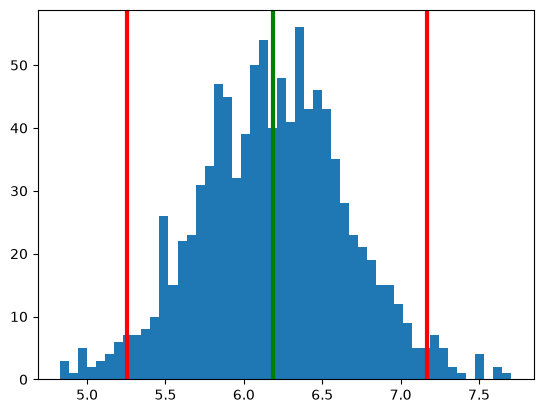

In [1428]:
n_iterations = 1000
stats = []

for i in range(n_iterations):
    # Generar muestra con reemplazo
    X_resample, y_resample = resample(X_test, y_test, replace=True, n_samples=len(X_test))

    # Predecir sobre la muestra completa (o sobre el set original)
    pred = mejor_modelo.predict(X_resample) # Evaluamos contra los datos originales
    
    rmse = np.sqrt(mean_squared_error(y_resample, pred))
    stats.append(rmse)

# Calcular percentiles para el intervalo de confianza al 95%
alpha = 0.95
p_lower = ((1.0 - alpha) / 2.0) * 100
p_upper = (alpha + (1.0 - alpha) / 2.0) * 100

lower = np.percentile(stats, p_lower)
upper = np.percentile(stats, p_upper)

print(f"Media del RMSE {np.mean(stats)}")
print(f"Intervalo de confianza del RMSE (95%): [{lower:.4f} a {upper:.4f}]")

plt.hist(stats, bins=50)
plt.axvline(lower, color='red', linewidth=3)
plt.axvline(np.mean(stats), color='green', linewidth=3)
plt.axvline(upper, color='red', linewidth=3)
plt.show()

## **Conclusion sobreajuste**

Para concluir, es evidente que el modelo presenta un problema serio de sobreajuste, en este caso para una regresion lineal de grados mayores a 2 se puede deber a lo siguiente: <br> **Explosión de dimensionalidad (Alta Varianza):** Al aplicar PolynomialFeatures(degree=2) sobre las 19 características numéricas originales, el espacio de variables creció exponencialmente. Esto, sumado a las variables categóricas codificadas, dio como resultado un modelo con 234 coeficientes. Un modelo con tantas variables es excesivamente complejo y tiende a ajustarse a variaciones aleatorias o "ruido". <br> **Baja proporción entre muestras y características:** El conjunto de entrenamiento (X_train) cuenta con 870 registros. Entrenar un modelo para que ajuste 234 parámetros diferentes utilizando solo 870 ejemplos otorga demasiada flexibilidad matemática. Esto permite que el modelo "memorice" los datos de entrenamiento (alcanzando un R2 de 0.82), pero fallará al intentar generalizar sobre datos no vistos. <br> **Multicolinealidad y ausencia de regularización:** Las características polinomiales generan interacciones multiplicativas y cuadráticas que están altamente correlacionadas entre sí. Al utilizar el estimador estándar LinearRegression(), el modelo no tiene ningún mecanismo de penalización para restringir el tamaño de los coeficientes. Esta falta de regularización hace que el modelo asigne pesos extremos para compensar las correlaciones, volviéndolo inestable y sobreajustado.  